Dataset Shape: (375, 6)

First Five Rows:


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB

Missing Values:
Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

Dataset Shape After Cleaning: (324, 6)


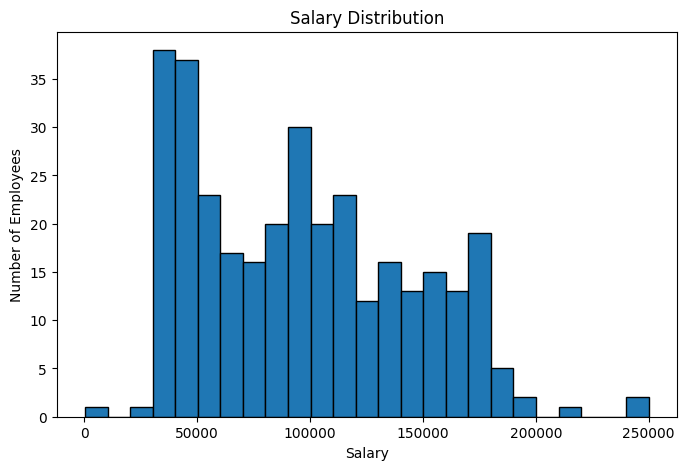

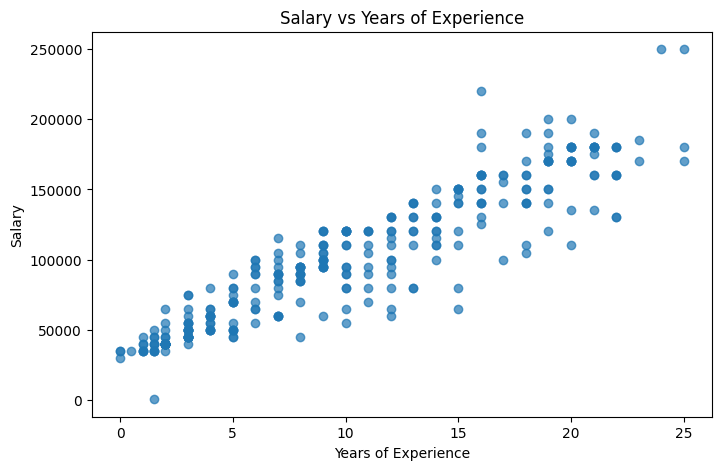

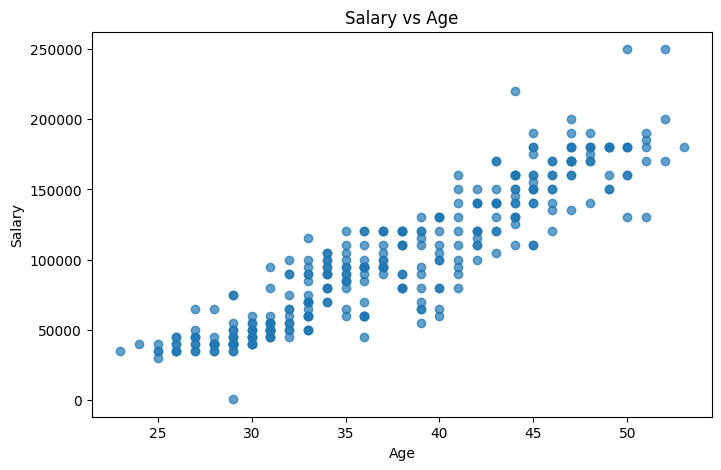


Features:
Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience'], dtype='object')

Numeric Features: ['Age', 'Years of Experience']
Categorical Features: ['Gender', 'Education Level', 'Job Title']
Training Data Shape: (259, 5)
Testing Data Shape: (65, 5)

Random Forest Regressor Performance
----------------------------------------
Mean Absolute Error: 10504.98
Mean Squared Error: 226241413.95
Root Mean Squared Error: 15041.32
R2 Score: 0.8803

Gradient Boosting Regressor Performance
----------------------------------------
Mean Absolute Error: 10705.06
Mean Squared Error: 213962340.46
Root Mean Squared Error: 14627.45
R2 Score: 0.8868

Extra Trees Regressor Performance
----------------------------------------
Mean Absolute Error: 10149.34
Mean Squared Error: 204246504.53
Root Mean Squared Error: 14291.48
R2 Score: 0.8919

Voting Regressor Ensemble Performance
----------------------------------------
Mean Absolute Error: 10324.99
Mean Squared Error: 207543858.37

,Model,MAE,RMSE,R2 Score
4,Stacking Regressor Ensemble,10342.313014,14186.562449,0.893502
2,Extra Trees Regressor,10149.339315,14291.483636,0.891921
3,Voting Regressor Ensemble,10324.991048,14406.382557,0.890176
1,Gradient Boosting Regressor,10705.056402,14627.451605,0.886780
0,Random Forest Regressor,10504.975940,15041.323544,0.880282


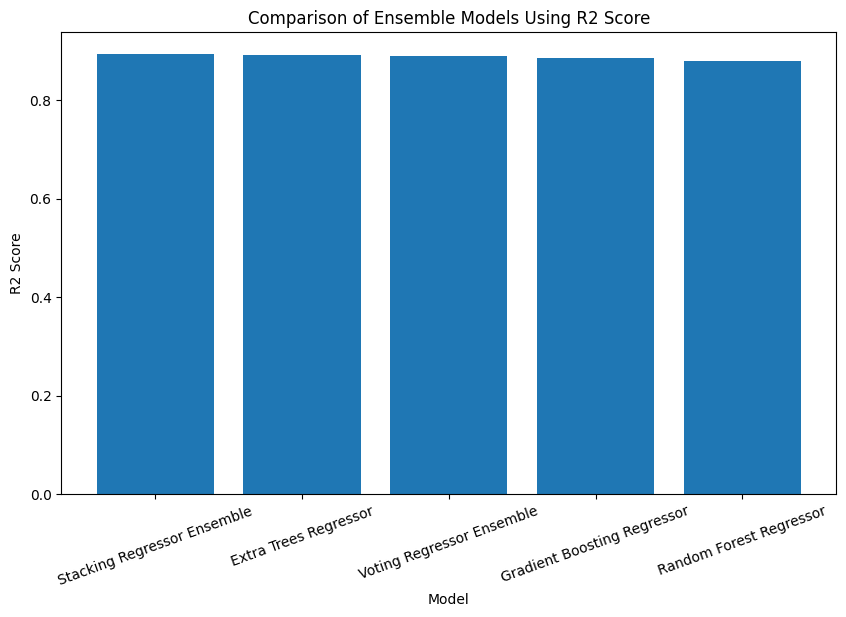

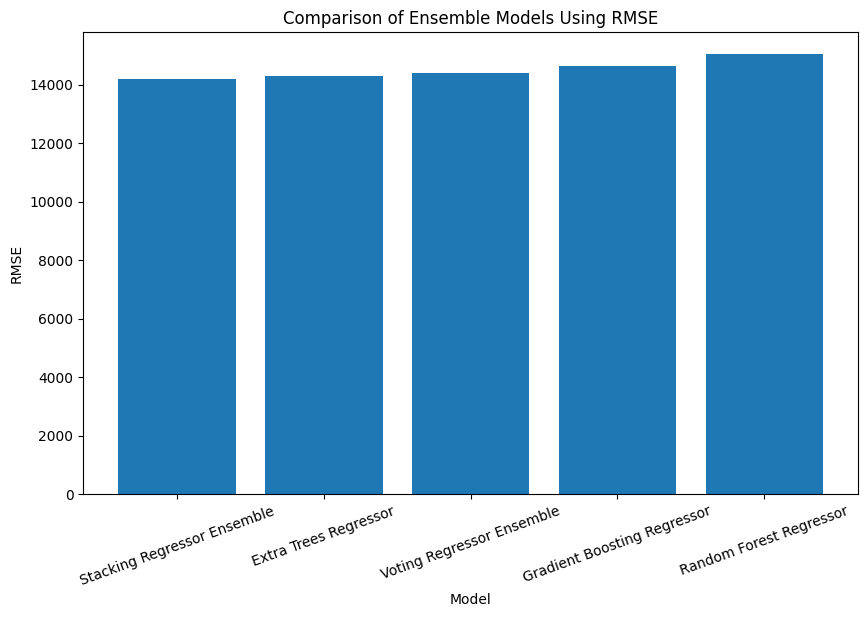

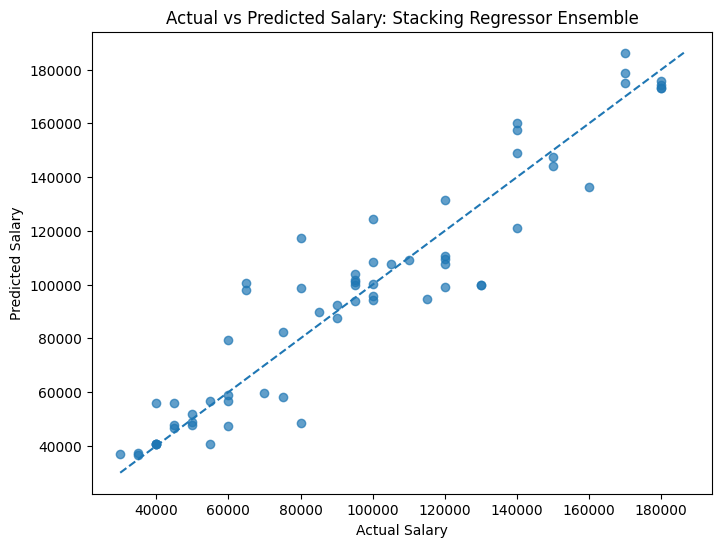


Sample Salary Predictions:


,Actual Salary,Predicted Salary,Difference
0,100000.0,108290.688720,-8290.688720
1,100000.0,124507.582657,-24507.582657
2,50000.0,52009.398524,-2009.398524
3,110000.0,109041.340063,958.659937
4,105000.0,107480.115523,-2480.115523
5,95000.0,100936.083256,-5936.083256
6,45000.0,47784.434452,-2784.434452
7,55000.0,56740.132989,-1740.132989
8,180000.0,173065.904191,6934.095809
9,40000.0,55990.739918,-15990.739918



Top 15 Important Features:


,Feature,Importance
1,num__Years of Experience,0.536451
0,num__Age,0.363228
4,cat__Education Level_Bachelor's,0.023483
8,cat__Job Title_Administrative Assistant,0.005325
6,cat__Education Level_PhD,0.005309
13,cat__Job Title_Chief Data Officer,0.005112
5,cat__Education Level_Master's,0.004240
14,cat__Job Title_Chief Technology Officer,0.003551
12,cat__Job Title_CEO,0.003545
92,cat__Job Title_Recruiter,0.003250


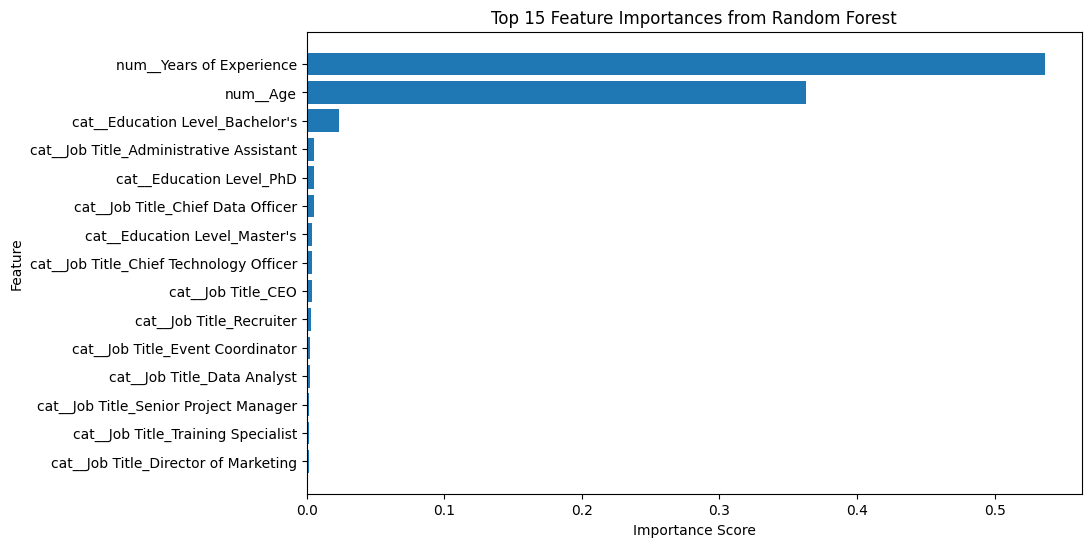


Final Conclusion
----------------------------------------
The best model is: Stacking Regressor Ensemble
Best R2 Score: 0.8935
Best RMSE: 14186.56
Best MAE: 10342.31


In [ ]:
# ============================================================
# SALARY PREDICTION USING ENSEMBLE LEARNING
# Dataset: Salary Data.csv
# ============================================================

# 1. Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor, VotingRegressor, StackingRegressor
from sklearn.linear_model import Ridge

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================================
# 2. Load Dataset
# ============================================================

df = pd.read_csv("Salary Data.csv")

print("Dataset Shape:", df.shape)
print("\nFirst Five Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

# ============================================================
# 3. Basic Data Cleaning
# ============================================================

# Remove duplicate records
df = df.drop_duplicates()

# Remove rows where Salary is missing because Salary is the target variable
df = df.dropna(subset=["Salary"])

print("\nDataset Shape After Cleaning:", df.shape)

# ============================================================
# 4. Exploratory Data Analysis
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(df["Salary"], bins=25, edgecolor="black")
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["Years of Experience"], df["Salary"], alpha=0.7)
plt.title("Salary vs Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["Age"], df["Salary"], alpha=0.7)
plt.title("Salary vs Age")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

# ============================================================
# 5. Define Features and Target
# ============================================================

X = df.drop("Salary", axis=1)
y = df["Salary"]

print("\nFeatures:")
print(X.columns)

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("\nNumeric Features:", numeric_features)
print("Categorical Features:", categorical_features)

# ============================================================
# 6. Data Preprocessing Pipeline
# ============================================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# ============================================================
# 7. Split Dataset into Training and Testing Data
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# ============================================================
# 8. Create Ensemble Learning Models
# ============================================================

random_forest_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_split=2,
    random_state=42
)

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

extra_trees_model = ExtraTreesRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42
)

# ============================================================
# 9. Train Individual Ensemble Models
# ============================================================

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", random_forest_model)
])

gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", gradient_boosting_model)
])

et_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", extra_trees_model)
])

rf_pipeline.fit(X_train, y_train)
gb_pipeline.fit(X_train, y_train)
et_pipeline.fit(X_train, y_train)

# ============================================================
# 10. Model Evaluation Function
# ============================================================

def evaluate_model(model, X_test, y_test, model_name):
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    print(f"\n{model_name} Performance")
    print("-" * 40)
    print("Mean Absolute Error:", round(mae, 2))
    print("Mean Squared Error:", round(mse, 2))
    print("Root Mean Squared Error:", round(rmse, 2))
    print("R2 Score:", round(r2, 4))

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2,
        "Predictions": predictions
    }

# ============================================================
# 11. Evaluate Individual Models
# ============================================================

rf_results = evaluate_model(
    rf_pipeline, X_test, y_test, "Random Forest Regressor"
)

gb_results = evaluate_model(
    gb_pipeline, X_test, y_test, "Gradient Boosting Regressor"
)

et_results = evaluate_model(
    et_pipeline, X_test, y_test, "Extra Trees Regressor"
)

# ============================================================
# 12. Voting Regressor Ensemble Model
# ============================================================

voting_model = VotingRegressor(
    estimators=[
        ("Random Forest", random_forest_model),
        ("Gradient Boosting", gradient_boosting_model),
        ("Extra Trees", extra_trees_model)
    ]
)

voting_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", voting_model)
])

voting_pipeline.fit(X_train, y_train)

voting_results = evaluate_model(
    voting_pipeline, X_test, y_test, "Voting Regressor Ensemble"
)

# ============================================================
# 13. Stacking Regressor Ensemble Model
# ============================================================

stacking_model = StackingRegressor(
    estimators=[
        ("Random Forest", random_forest_model),
        ("Gradient Boosting", gradient_boosting_model),
        ("Extra Trees", extra_trees_model)
    ],
    final_estimator=Ridge(),
    cv=5
)

stacking_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", stacking_model)
])

stacking_pipeline.fit(X_train, y_train)

stacking_results = evaluate_model(
    stacking_pipeline, X_test, y_test, "Stacking Regressor Ensemble"
)

# ============================================================
# 14. Compare All Models
# ============================================================

results_df = pd.DataFrame([
    {
        "Model": rf_results["Model"],
        "MAE": rf_results["MAE"],
        "RMSE": rf_results["RMSE"],
        "R2 Score": rf_results["R2 Score"]
    },
    {
        "Model": gb_results["Model"],
        "MAE": gb_results["MAE"],
        "RMSE": gb_results["RMSE"],
        "R2 Score": gb_results["R2 Score"]
    },
    {
        "Model": et_results["Model"],
        "MAE": et_results["MAE"],
        "RMSE": et_results["RMSE"],
        "R2 Score": et_results["R2 Score"]
    },
    {
        "Model": voting_results["Model"],
        "MAE": voting_results["MAE"],
        "RMSE": voting_results["RMSE"],
        "R2 Score": voting_results["R2 Score"]
    },
    {
        "Model": stacking_results["Model"],
        "MAE": stacking_results["MAE"],
        "RMSE": stacking_results["RMSE"],
        "R2 Score": stacking_results["R2 Score"]
    }
])

results_df = results_df.sort_values(by="R2 Score", ascending=False)

print("\nModel Comparison:")
display(results_df)

# ============================================================
# 15. Visualize Model Performance
# ============================================================

plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.title("Comparison of Ensemble Models Using R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Comparison of Ensemble Models Using RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.show()

# ============================================================
# 16. Actual vs Predicted Salary Plot
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

if best_model_name == "Random Forest Regressor":
    best_predictions = rf_results["Predictions"]
elif best_model_name == "Gradient Boosting Regressor":
    best_predictions = gb_results["Predictions"]
elif best_model_name == "Extra Trees Regressor":
    best_predictions = et_results["Predictions"]
elif best_model_name == "Voting Regressor Ensemble":
    best_predictions = voting_results["Predictions"]
else:
    best_predictions = stacking_results["Predictions"]

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_predictions, alpha=0.7)

minimum_value = min(y_test.min(), best_predictions.min())
maximum_value = max(y_test.max(), best_predictions.max())

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.title(f"Actual vs Predicted Salary: {best_model_name}")
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.show()

# ============================================================
# 17. Sample Predictions
# ============================================================

prediction_comparison = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": best_predictions,
    "Difference": y_test.values - best_predictions
})

print("\nSample Salary Predictions:")
display(prediction_comparison.head(10))

# ============================================================
# 18. Feature Importance Using Random Forest
# ============================================================

# Fit preprocessing separately to extract transformed feature names
preprocessor.fit(X_train)

encoded_feature_names = preprocessor.get_feature_names_out()

rf_model_trained = rf_pipeline.named_steps["model"]

feature_importance_df = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Importance": rf_model_trained.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).head(15)

print("\nTop 15 Important Features:")
display(feature_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.title("Top 15 Feature Importances from Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

# ============================================================
# 19. Final Conclusion
# ============================================================

best_result = results_df.iloc[0]

print("\nFinal Conclusion")
print("-" * 40)
print(f"The best model is: {best_result['Model']}")
print(f"Best R2 Score: {best_result['R2 Score']:.4f}")
print(f"Best RMSE: {best_result['RMSE']:.2f}")
print(f"Best MAE: {best_result['MAE']:.2f}")